In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
df = pd.read_csv(url)
print("Original dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Original dataset shape: (19735, 29)

First 5 rows:
                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.13333

In [45]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

In [46]:
print("Missing values:")
print(df.isnull().sum().sum())

Missing values:
0


In [47]:
hourly = df.resample("1h").mean()
y = hourly["Appliances"].dropna()

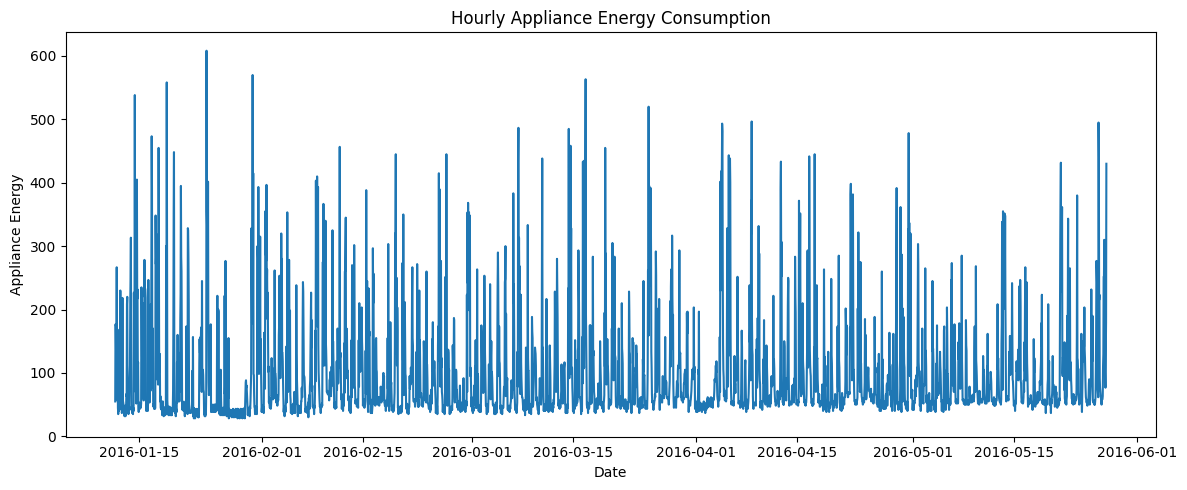

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(y)
plt.title("Hourly Appliance Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Appliance Energy")
plt.tight_layout()
plt.show()

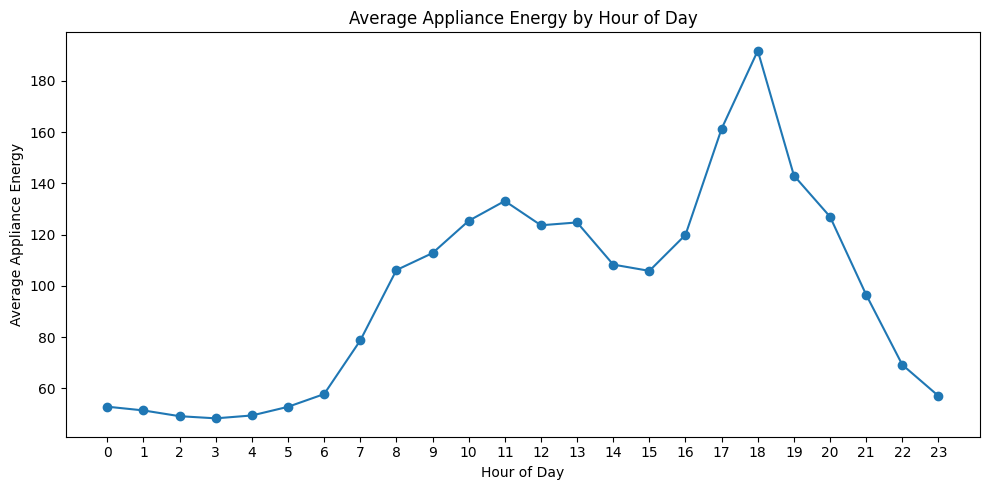

In [49]:
hourly["hour"] = hourly.index.hour
hourly_by_hour = hourly.groupby("hour")["Appliances"].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_by_hour.index, hourly_by_hour.values, marker="o")
plt.title("Average Appliance Energy by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Appliance Energy")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

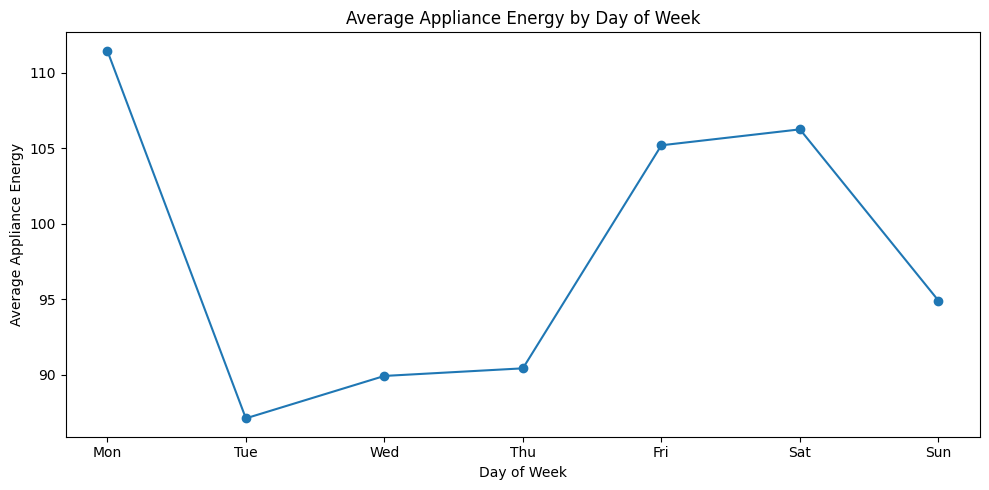

In [50]:
hourly["day"] = hourly.index.dayofweek
hourly_by_day = hourly.groupby("day")["Appliances"].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_by_day.index, hourly_by_day.values, marker="o")
plt.title("Average Appliance Energy by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Appliance Energy")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.tight_layout()
plt.show()

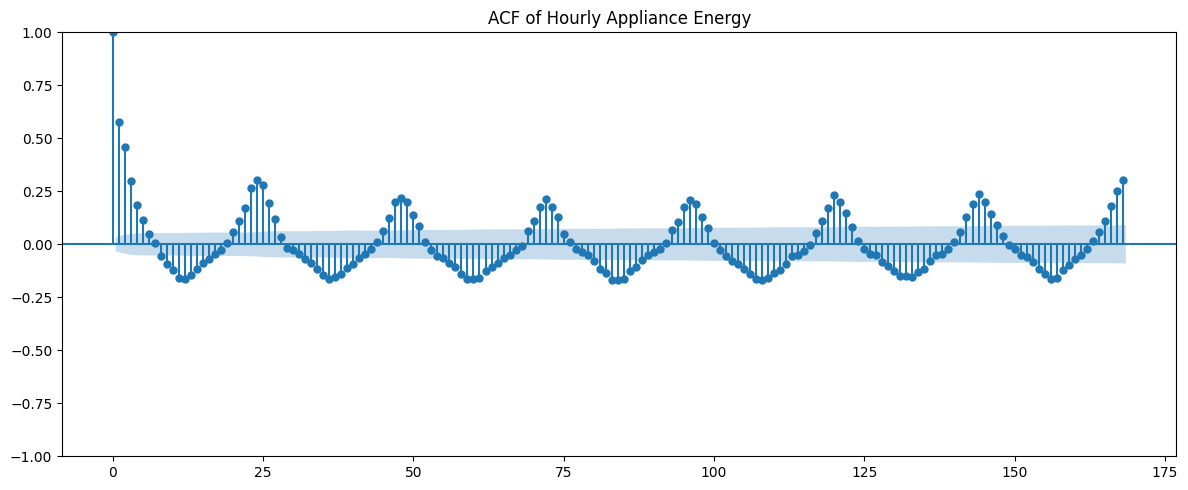

In [51]:
plt.figure(figsize=(12, 5))
plot_acf(y, lags=168, ax=plt.gca())
plt.title("ACF of Hourly Appliance Energy")
plt.tight_layout()
plt.show()

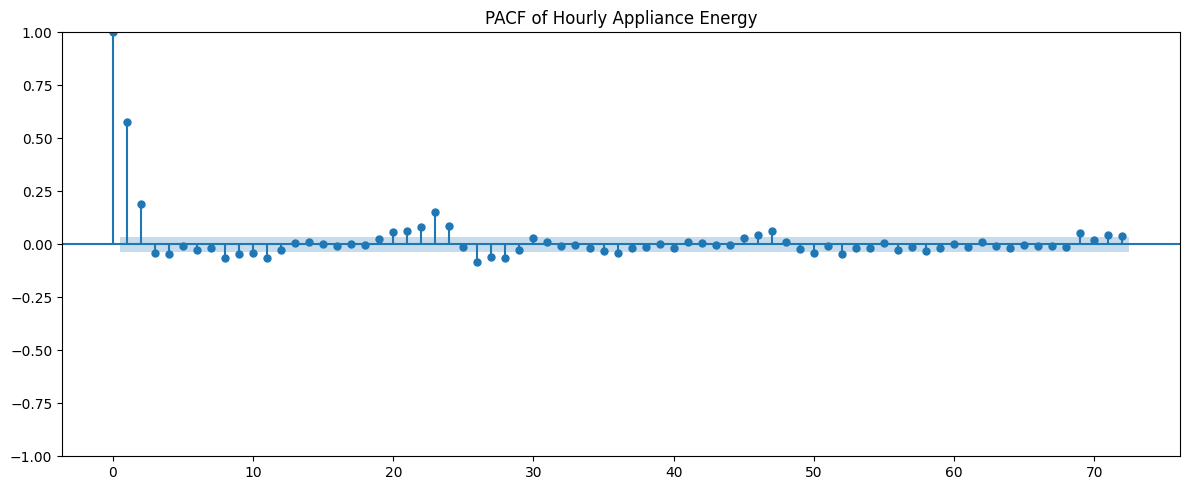

In [52]:
plt.figure(figsize=(12, 5))
plot_pacf(y, lags=72, ax=plt.gca(), method="ywm")
plt.title("PACF of Hourly Appliance Energy")
plt.tight_layout()
plt.show()

In [53]:
daily_corr = y.autocorr(lag=24)
weekly_corr = y.autocorr(lag=168)
print("\nSeasonality check:")
print("Lag 24 (daily):", daily_corr)
print("Lag 168 (weekly):", weekly_corr)


Seasonality check:
Lag 24 (daily): 0.30729403712800546
Lag 168 (weekly): 0.32823351373013854


In [54]:
adf = adfuller(y)
print("\nADF Test:")
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])
if adf[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is non-stationary.")


ADF Test:
ADF Statistic: -8.948888280256888
p-value: 8.833753129594426e-15
The series is stationary.


In [55]:
y_diff = y.diff().dropna()
adf_diff = adfuller(y_diff)
print("\nADF Test after first differencing:")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])
if adf_diff[1] < 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is non-stationary.")


ADF Test after first differencing:
ADF Statistic: -16.952574397050608
p-value: 9.437199196924238e-30
The differenced series is stationary.


# PART 2: FORECASTING PROBLEM


In [56]:
#Forecast horizon
forecast_horizon = 24

In [57]:
train = y.iloc[:-forecast_horizon]
test = y.iloc[-forecast_horizon:]

In [58]:
print("\nForecasting setup:")
print("Target variable: Appliances")
print("Forecast horizon:", forecast_horizon, "hours")
print("Training observations:", len(train))
print("Testing observations:", len(test))
print("\nTraining period:")
print(train.index[0], "to", train.index[-1])
print("\nTesting period:")
print(test.index[0], "to", test.index[-1])


Forecasting setup:
Target variable: Appliances
Forecast horizon: 24 hours
Training observations: 3266
Testing observations: 24

Training period:
2016-01-11 17:00:00 to 2016-05-26 18:00:00

Testing period:
2016-05-26 19:00:00 to 2016-05-27 18:00:00


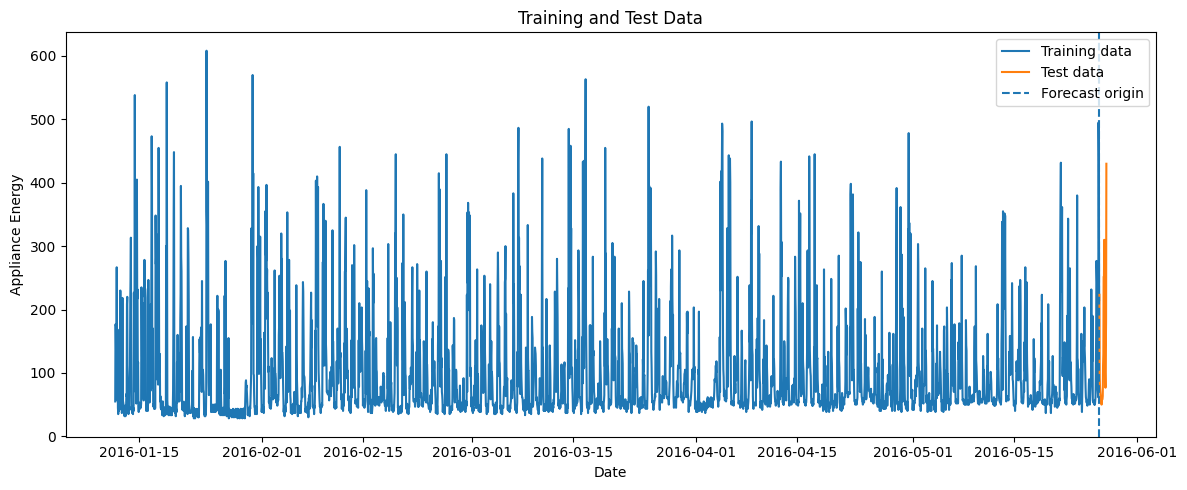

In [59]:
plt.figure(figsize=(12, 5))
plt.plot(train, label="Training data")
plt.plot(test, label="Test data")
plt.axvline(test.index[0], linestyle="--", label="Forecast origin")
plt.title("Training and Test Data")
plt.xlabel("Date")
plt.ylabel("Appliance Energy")
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

In [61]:
forecast_setup = {
    "target": "Appliances",
    "frequency": "Hourly",
    "forecast_horizon": 24,
    "training_observations": len(train),
    "testing_observations": len(test),
    "evaluation_metrics": [
        "MAE",
        "RMSE",
        "MAPE"
    ]
}
print("\n" + "=" * 60)
print("FORECASTING PROBLEM")
print("=" * 60)
for key, value in forecast_setup.items():
    print(f"{key}: {value}")


FORECASTING PROBLEM
target: Appliances
frequency: Hourly
forecast_horizon: 24
training_observations: 3266
testing_observations: 24
evaluation_metrics: ['MAE', 'RMSE', 'MAPE']


# PART 3: BENCHMARK FORECASTING MODELS

In [62]:
mean_forecast = pd.Series(train.mean(),index=test.index)

In [63]:
naive_forecast = pd.Series(train.iloc[-1],index=test.index)

In [64]:
daily_seasonal_forecast = train.iloc[-24:].values
daily_seasonal_forecast = pd.Series(daily_seasonal_forecast,index=test.index)

In [65]:
weekly_seasonal_forecast = train.iloc[-168:].iloc[:24].values
weekly_seasonal_forecast = pd.Series(weekly_seasonal_forecast[-24:],index=test.index)

In [66]:
first_value = train.iloc[0]
last_value = train.iloc[-1]
drift =(last_value-first_value)/(len(train)-1)
drift_forecast = pd.Series(
    [
        last_value + drift*step
        for step in range(1, forecast_horizon + 1)
    ],
    index=test.index
)

In [67]:
benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Daily Seasonal Naive": daily_seasonal_forecast,
    "Weekly Seasonal Naive": weekly_seasonal_forecast,
    "Drift": drift_forecast
}

In [68]:
benchmark_results = []
for model_name, forecast in benchmark_forecasts.items():
  mae, rmse, mape = calculate_metrics(test, forecast)
  benchmark_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })
benchmark_results = pd.DataFrame(benchmark_results)
print("\n" + "=" * 60)
print("BENCHMARK MODEL RESULTS")
print("=" * 60)
print(benchmark_results.sort_values("RMSE").to_string(index=False))


BENCHMARK MODEL RESULTS
                Model        MAE       RMSE   MAPE (%)
                 Mean  74.513889 107.630886  49.177814
 Daily Seasonal Naive  63.680556 113.640821  38.927863
Weekly Seasonal Naive  74.305556 117.972847  36.749262
                Naive 111.736111 124.032832 138.838358
                Drift 111.972967 124.261749 139.257256


# PART 4: SARIMAX MODEL

In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

In [70]:
adf_result = adfuller(train)
print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])
if adf_result[1] < 0.05:
    print("Training data is stationary.")
    d_test = 0
else:

    print("Training data is non-stationary.")
    d_test = 1
    differenced_train = train.diff().dropna()
    adf_diff = adfuller(differenced_train)
    print("\nADF p-value after differencing:", adf_diff[1])
    if adf_diff[1] < 0.05:
        print("Differenced data is stationary.")
    else:
        print("Differenced data is still non-stationary.")

ADF Statistic: -9.016389491844526
ADF p-value: 5.934864745699956e-15
Training data is stationary.


In [71]:
hourly["hour_sin"] = np.sin(2 * np.pi * hourly.index.hour / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * hourly.index.hour / 24)
sarimax_features = ["T_out","RH_out","Windspeed","hour_sin","hour_cos"]
exog_train = hourly.loc[train.index, sarimax_features]
exog_test = hourly.loc[test.index, sarimax_features]
print("SARIMAX exogenous variables:")
print(sarimax_features)

SARIMAX exogenous variables:
['T_out', 'RH_out', 'Windspeed', 'hour_sin', 'hour_cos']


In [72]:
aic_results = []
best_aic = np.inf
best_order = None
best_model = None
total_models = 7 * 3 * 7
count = 0
for p in range(7):
    for d in range(3):
        for q in range(7):
            count += 1
            print(f"Testing model {count}/{total_models}: "f"({p},{d},{q})")
            try:
                model = SARIMAX(
                    train,
                    exog=exog_train,
                    order=(p, d, q),
                    seasonal_order=(1, 0, 1, 24),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted_model = model.fit(disp=False)
                aic = fitted_model.aic
                aic_results.append([p, d, q, aic])
                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
                    best_model = fitted_model
            except Exception:
                continue
print("\nBest SARIMA order:", best_order)
print("Seasonal order:")
print("Best AIC:", best_aic)

Testing model 1/147: (0,0,0)
Testing model 2/147: (0,0,1)
Testing model 3/147: (0,0,2)
Testing model 4/147: (0,0,3)
Testing model 5/147: (0,0,4)
Testing model 6/147: (0,0,5)
Testing model 7/147: (0,0,6)
Testing model 8/147: (0,1,0)
Testing model 9/147: (0,1,1)
Testing model 10/147: (0,1,2)
Testing model 11/147: (0,1,3)
Testing model 12/147: (0,1,4)
Testing model 13/147: (0,1,5)
Testing model 14/147: (0,1,6)
Testing model 15/147: (0,2,0)
Testing model 16/147: (0,2,1)
Testing model 17/147: (0,2,2)
Testing model 18/147: (0,2,3)
Testing model 19/147: (0,2,4)
Testing model 20/147: (0,2,5)
Testing model 21/147: (0,2,6)
Testing model 22/147: (1,0,0)
Testing model 23/147: (1,0,1)
Testing model 24/147: (1,0,2)
Testing model 25/147: (1,0,3)
Testing model 26/147: (1,0,4)
Testing model 27/147: (1,0,5)
Testing model 28/147: (1,0,6)
Testing model 29/147: (1,1,0)
Testing model 30/147: (1,1,1)
Testing model 31/147: (1,1,2)
Testing model 32/147: (1,1,3)
Testing model 33/147: (1,1,4)
Testing model 34/14

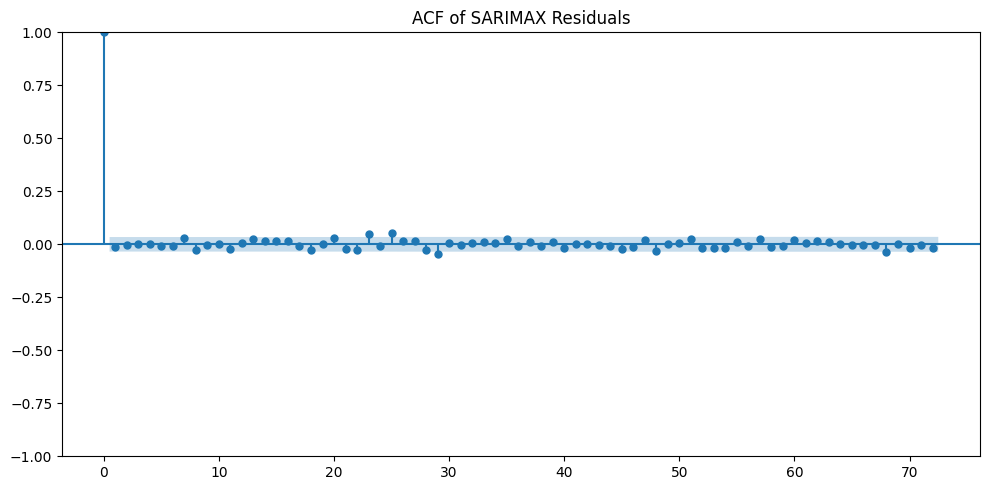

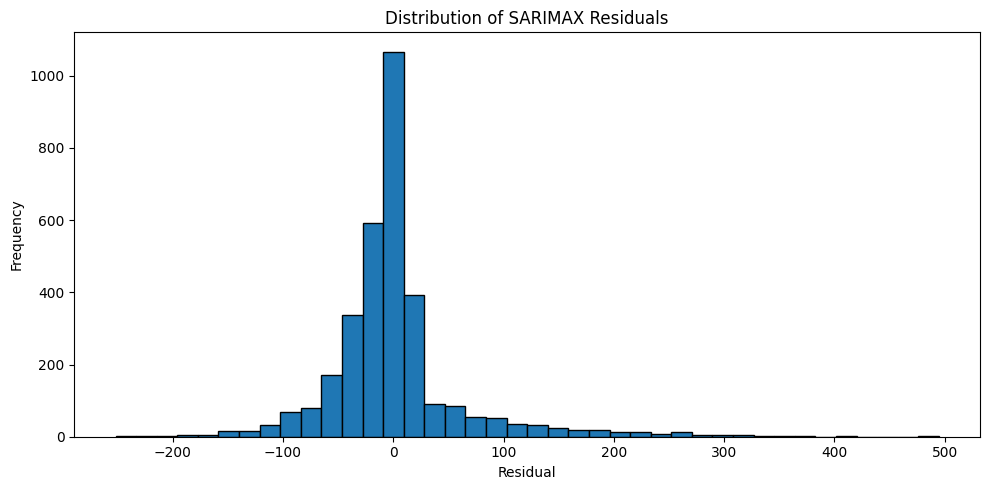

In [73]:
residuals = best_model.resid.dropna()
# Residual ACF
plt.figure(figsize=(10, 5))
plot_acf(residuals,lags=72,ax=plt.gca())
plt.title("ACF of SARIMAX Residuals")
plt.tight_layout()
plt.show()
# Residual distribution
plt.figure(figsize=(10, 5))
plt.hist(residuals,bins=40,edgecolor="black")
plt.title("Distribution of SARIMAX Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [74]:
forecast_result = best_model.get_forecast(steps=24,exog=exog_test)
forecast = forecast_result.predicted_mean
confidence_interval = forecast_result.conf_int()

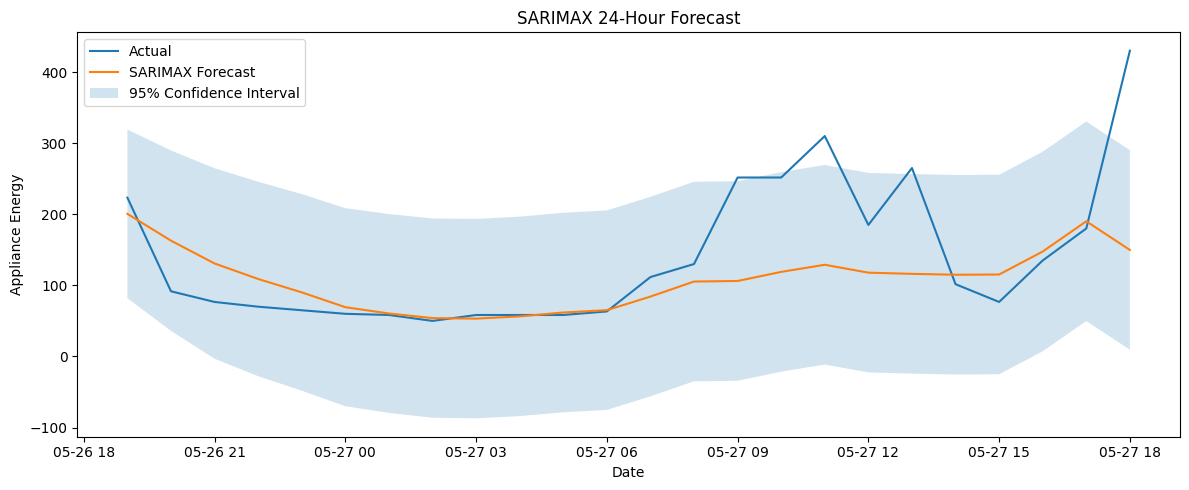

In [75]:
plt.figure(figsize=(12, 5))
plt.plot(test.index,test.values,label="Actual")
plt.plot(
    forecast.index,
    forecast.values,
    label="SARIMAX Forecast"
)
plt.fill_between(
    forecast.index,
    confidence_interval.iloc[:, 0],
    confidence_interval.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.title("SARIMAX 24-Hour Forecast")
plt.xlabel("Date")
plt.ylabel("Appliance Energy")
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
rmse = np.sqrt(mean_squared_error(test,forecast))
print("\nSARIMAX RMSE:", rmse)


SARIMAX RMSE: 89.1690076771477


# PART 5: FEATURE / COVARIATE ENGINEERING

In [77]:
features = hourly.copy()
sensor_features = [
    "T1", "RH_1",
    "T2", "RH_2",
    "T3", "RH_3",
    "T4", "RH_4",
    "T5", "RH_5",
    "T6", "RH_6",
    "T7", "RH_7",
    "T8", "RH_8",
    "T9", "RH_9"
]

In [78]:
weather_features = [
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint"
]

In [79]:
features["hour"] = features.index.hour
features["day_of_week"] = features.index.dayofweek
features["is_weekend"] = (
    features["day_of_week"] >= 5
).astype(int)

In [80]:
features["hour_sin"] = np.sin(2 * np.pi * features["hour"] / 24)
features["hour_cos"] = np.cos(2 * np.pi * features["hour"] / 24)

In [81]:
features["Appliances_lag_1"] = (features["Appliances"].shift(1))
features["Appliances_lag_24"] = (features["Appliances"].shift(24))
features["Appliances_lag_168"] = (features["Appliances"].shift(168))

In [82]:
features["Appliances_rolling_24"] = (
    features["Appliances"]
    .shift(1)
    .rolling(24)
    .mean()
)
features["Appliances_rolling_168"] = (
    features["Appliances"]
    .shift(1)
    .rolling(168)
    .mean()
)

In [83]:
feature_columns = (
    sensor_features
    + weather_features
    + [
        "hour",
        "day_of_week",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "Appliances_lag_1",
        "Appliances_lag_24",
        "Appliances_lag_168",
        "Appliances_rolling_24",
        "Appliances_rolling_168"
    ]
)

In [84]:
model_data = features[["Appliances"] + feature_columns].dropna()
print("Feature dataset shape:", model_data.shape)
print("\nFeatures used:")
for feature in feature_columns:
    print(feature)
print("\nFirst five rows:")
print(model_data.head())

Feature dataset shape: (3122, 35)

Features used:
T1
RH_1
T2
RH_2
T3
RH_3
T4
RH_4
T5
RH_5
T6
RH_6
T7
RH_7
T8
RH_8
T9
RH_9
T_out
Press_mm_hg
RH_out
Windspeed
Visibility
Tdewpoint
hour
day_of_week
is_weekend
hour_sin
hour_cos
Appliances_lag_1
Appliances_lag_24
Appliances_lag_168
Appliances_rolling_24
Appliances_rolling_168

First five rows:
                     Appliances         T1       RH_1         T2       RH_2  \
date                                                                          
2016-01-18 17:00:00   35.000000  19.172222  41.175556  17.962222  41.530000   
2016-01-18 18:00:00  300.000000  19.100000  41.075556  17.812222  41.527778   
2016-01-18 19:00:00  195.000000  19.574444  42.057778  18.263750  42.203889   
2016-01-18 20:00:00  558.333333  20.258611  41.407083  19.100556  42.037778   
2016-01-18 21:00:00  345.000000  20.642222  40.164444  19.583788  40.143586   

                            T3       RH_3         T4       RH_4         T5  \
date                       

# PART 6: FEATURE-BASED REGRESSION MODEL

In [85]:
X = model_data[feature_columns]
y = model_data["Appliances"]

In [86]:
test_size = 14 * 24
X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]
y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 2786
Testing observations: 336


In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [88]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [89]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)
print("\nTop 15 Random Forest Features:")
print(feature_importance.head(15))


Top 15 Random Forest Features:
                   Feature  Importance
29        Appliances_lag_1    0.395082
30       Appliances_lag_24    0.043319
28                hour_cos    0.042256
31      Appliances_lag_168    0.035871
27                hour_sin    0.029247
33  Appliances_rolling_168    0.026460
5                     RH_3    0.025242
32   Appliances_rolling_24    0.024184
4                       T3    0.020600
19             Press_mm_hg    0.020147
1                     RH_1    0.019906
9                     RH_5    0.019527
2                       T2    0.018061
8                       T5    0.017676
22              Visibility    0.016794


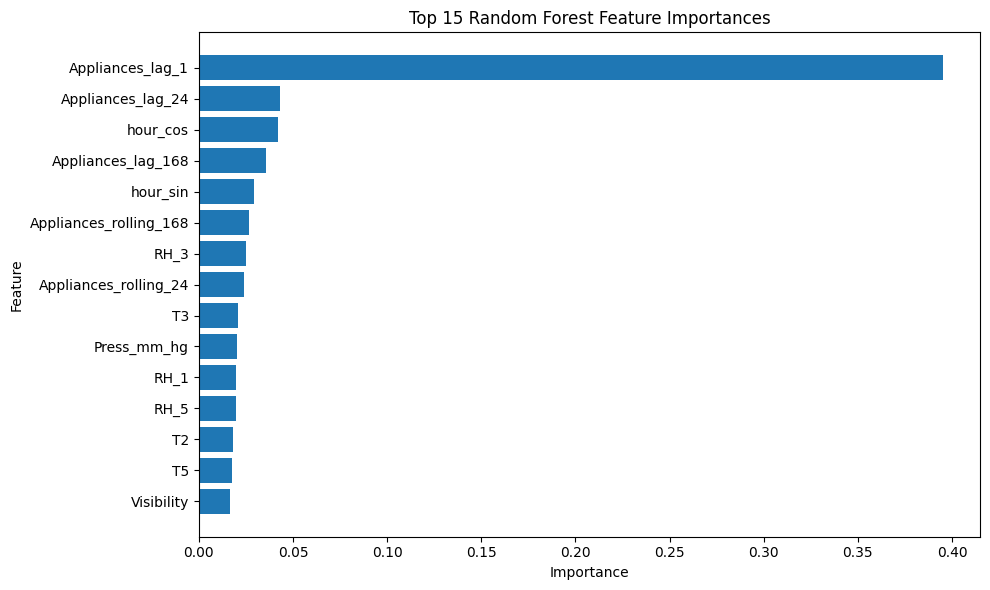

In [90]:
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [91]:
forecast_start = y_train.index[-1] + pd.Timedelta(hours=1)
forecast_index = y_test.loc[forecast_start:].index[:24]
history = y_train.copy()
rf_predictions = []
for current_time in forecast_index:
    row = {}
    for feature in sensor_features + weather_features:
        row[feature] = features.loc[current_time, feature]
    # Time features
    hour = current_time.hour
    day_of_week = current_time.dayofweek
    row["hour"] = hour
    row["day_of_week"] = day_of_week
    row["is_weekend"] = int(day_of_week >= 5)
    row["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    row["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    row["Appliances_lag_1"] = history.iloc[-1]
    row["Appliances_lag_24"] = history.iloc[-24]
    row["Appliances_lag_168"] = history.iloc[-168]
    row["Appliances_rolling_24"] = history.iloc[-24:].mean()
    row["Appliances_rolling_168"] = history.iloc[-168:].mean()
    X_future = pd.DataFrame(
        [row],
        index=[current_time]
    )[feature_columns]
    prediction = rf_model.predict(X_future)[0]
    rf_predictions.append(prediction)
    history.loc[current_time] = prediction
rf_forecast = pd.Series(rf_predictions,index=forecast_index)
y_actual_24 = y_test.loc[forecast_index]
rf_mae = mean_absolute_error(y_actual_24,rf_forecast)
rf_rmse = np.sqrt(mean_squared_error(y_actual_24,rf_forecast))
non_zero = y_actual_24 != 0
rf_mape = np.mean(
    np.abs(
        (
            y_actual_24[non_zero]
            - rf_forecast[non_zero]
        )
        / y_actual_24[non_zero]
    )
) * 100
print("\nRandom Forest 24-Hour Forecast Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE (%):", rf_mape)


Random Forest 24-Hour Forecast Results
MAE: 64.30590277777777
RMSE: 77.95248703136419
MAPE (%): 72.60358914522365


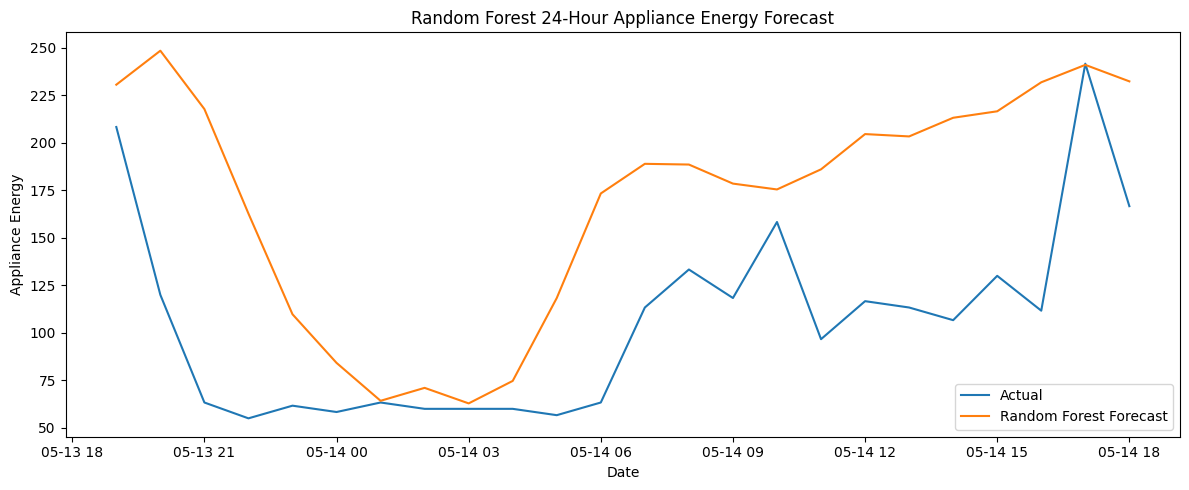

In [92]:
plt.figure(figsize=(12, 5))
plt.plot(
    y_actual_24.index,
    y_actual_24.values,
    label="Actual"
)
plt.plot(
    rf_forecast.index,
    rf_forecast.values,
    label="Random Forest Forecast"
)
plt.title("Random Forest 24-Hour Appliance Energy Forecast")
plt.xlabel("Date")
plt.ylabel("Appliance Energy")
plt.legend()
plt.tight_layout()
plt.show()

# PART 7: TIME-SERIES FOUNDATION MODEL - CHRONOS

In [93]:
!pip install -q chronos-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 3.5 MB/s eta 0:00:00


In [94]:
import torch
from chronos import BaseChronosPipeline
pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-small",device_map="cpu",torch_dtype=torch.float32)

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  191MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

In [95]:
context = torch.tensor(train.values,dtype=torch.float32)

In [96]:
forecast_output = pipeline.predict(context,prediction_length=24)

In [97]:
chronos_forecast = forecast_output[0, 4, :].numpy()
chronos_forecast = pd.Series(chronos_forecast,index=test.index)

In [98]:
chronos_mae, chronos_rmse, chronos_mape = calculate_metrics(test,chronos_forecast)
print("\n" + "=" * 60)
print("CHRONOS-BOLT 24-HOUR FORECAST")
print("=" * 60)
print("MAE:", chronos_mae)
print("RMSE:", chronos_rmse)
print("MAPE (%):", chronos_mape)


CHRONOS-BOLT 24-HOUR FORECAST
MAE: 48.41217512554592
RMSE: 83.24336388906329
MAPE (%): 23.685340284564983


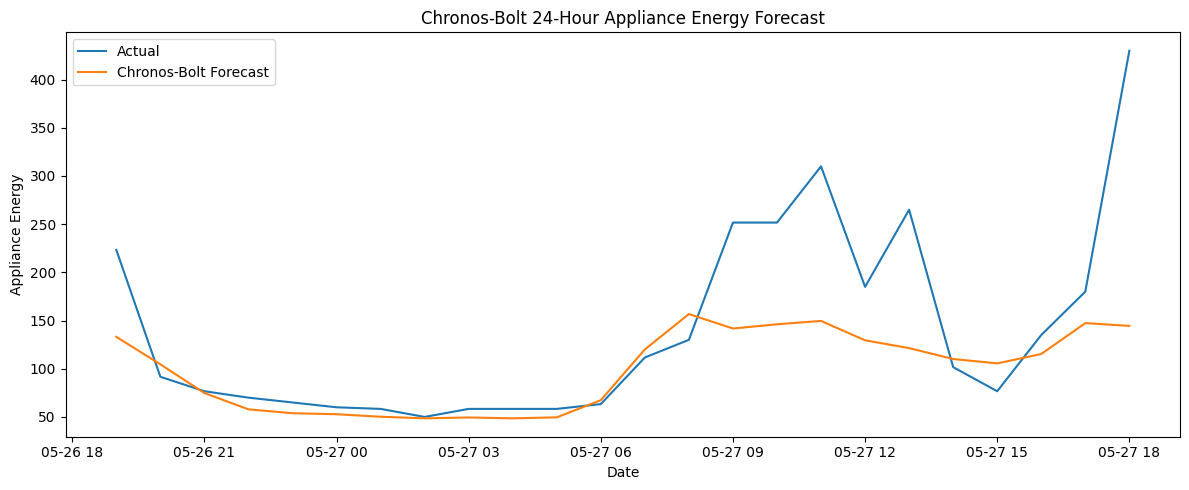

In [99]:
plt.figure(figsize=(12, 5))
plt.plot(
    test.index,
    test.values,
    label="Actual"
)
plt.plot(
    chronos_forecast.index,
    chronos_forecast.values,
    label="Chronos-Bolt Forecast"
)
plt.title("Chronos-Bolt 24-Hour Appliance Energy Forecast")
plt.xlabel("Date")
plt.ylabel("Appliance Energy")
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
chronos_result = pd.DataFrame({
    "Model": ["Chronos-Bolt"],
    "MAE": [chronos_mae],
    "RMSE": [chronos_rmse],
    "MAPE (%)": [chronos_mape]
})
comparison = pd.concat(
    [
        benchmark_results,
        chronos_result
    ],
    ignore_index=True)
print("\n" + "=" * 60)
print("BENCHMARK VS CHRONOS")
print("=" * 60)
print(comparison.sort_values("RMSE").to_string(index=False))


BENCHMARK VS CHRONOS
                Model        MAE       RMSE   MAPE (%)
         Chronos-Bolt  48.412175  83.243364  23.685340
                 Mean  74.513889 107.630886  49.177814
 Daily Seasonal Naive  63.680556 113.640821  38.927863
Weekly Seasonal Naive  74.305556 117.972847  36.749262
                Naive 111.736111 124.032832 138.838358
                Drift 111.972967 124.261749 139.257256


# PART 8: MODEL EVALUATION AND COMPARISON

In [101]:
all_forecasts = benchmark_forecasts.copy()
all_forecasts["SARIMAX"] = forecast
all_forecasts["Random Forest"] = rf_forecast
all_forecasts["Chronos-Bolt"] = chronos_forecast

In [102]:
evaluation_results = []
for model_name, predictions in all_forecasts.items():
    actual = np.asarray(test)
    predicted = np.asarray(predictions)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    non_zero = actual != 0
    mape = np.mean(np.abs((actual[non_zero] - predicted[non_zero])/ actual[non_zero])) * 100
    evaluation_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })
evaluation_results = pd.DataFrame(evaluation_results)
print(
    evaluation_results
    .sort_values("RMSE")
    .to_string(index=False)
)

                Model        MAE       RMSE   MAPE (%)
         Chronos-Bolt  48.412175  83.243364  23.685340
              SARIMAX  55.081561  89.169008  31.217149
        Random Forest  74.255903  90.487670  68.999099
                 Mean  74.513889 107.630886  49.177814
 Daily Seasonal Naive  63.680556 113.640821  38.927863
Weekly Seasonal Naive  74.305556 117.972847  36.749262
                Naive 111.736111 124.032832 138.838358
                Drift 111.972967 124.261749 139.257256


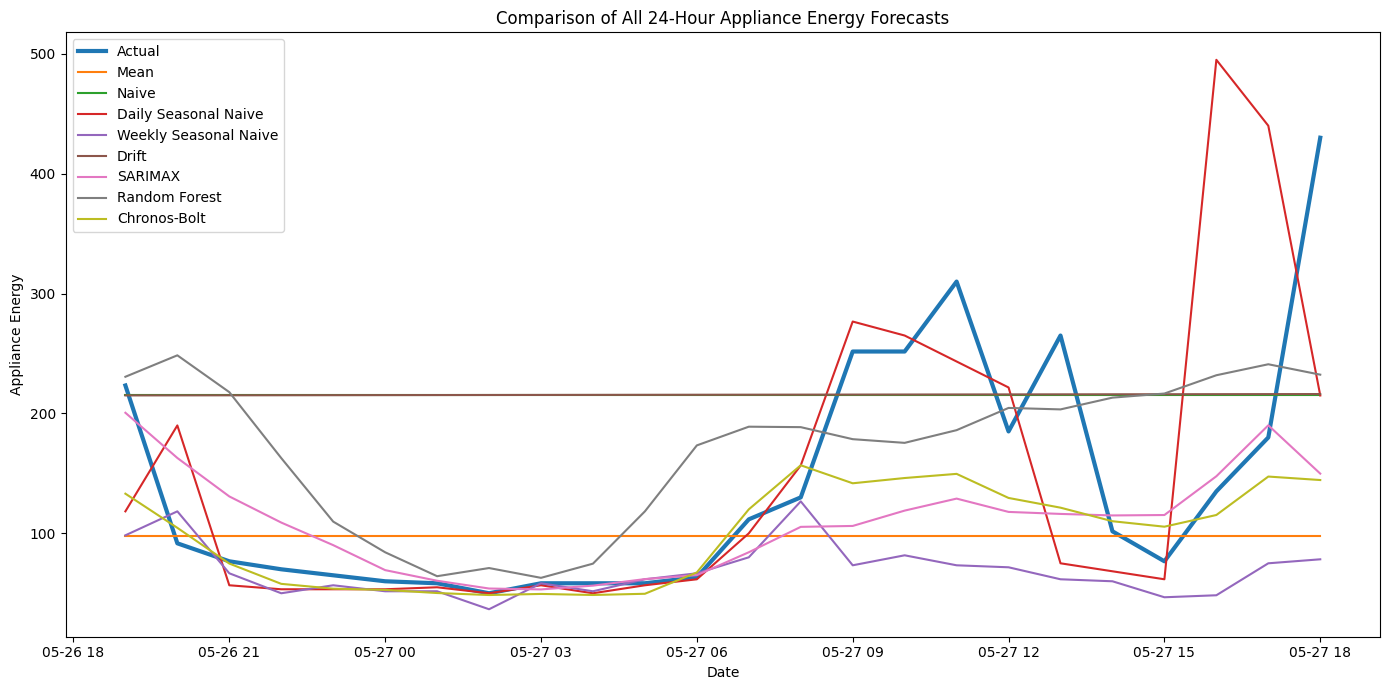

In [103]:
plt.figure(figsize=(14, 7))
plt.plot(
    test.index,
    test.values,
    label="Actual",
    linewidth=3
)
for model_name, predictions in all_forecasts.items():
    plt.plot(
        test.index,
        predictions,
        label=model_name
    )
plt.title("Comparison of All 24-Hour Appliance Energy Forecasts")
plt.xlabel("Date")
plt.ylabel("Appliance Energy")
plt.legend()
plt.tight_layout()
plt.show()

In [104]:
print("\n" + "=" * 70)
print("ALL MODEL PERFORMANCE")
print("=" * 70)
print(
    evaluation_results
    .sort_values("RMSE")
    .to_string(index=False)
)


ALL MODEL PERFORMANCE
                Model        MAE       RMSE   MAPE (%)
         Chronos-Bolt  48.412175  83.243364  23.685340
              SARIMAX  55.081561  89.169008  31.217149
        Random Forest  74.255903  90.487670  68.999099
                 Mean  74.513889 107.630886  49.177814
 Daily Seasonal Naive  63.680556 113.640821  38.927863
Weekly Seasonal Naive  74.305556 117.972847  36.749262
                Naive 111.736111 124.032832 138.838358
                Drift 111.972967 124.261749 139.257256


In [105]:
benchmark_best = benchmark_results.loc[benchmark_results["RMSE"].idxmin()]
strongest_benchmark = benchmark_best["Model"]
strongest_benchmark_rmse = benchmark_best["RMSE"]
print("\n" + "=" * 70)
print("STRONGEST BENCHMARK")
print("=" * 70)
print("Model:", strongest_benchmark)
print("RMSE:", strongest_benchmark_rmse)


STRONGEST BENCHMARK
Model: Mean
RMSE: 107.63088628581013


In [106]:
comparison = evaluation_results.copy()
comparison["RMSE Improvement (%)"] = ((strongest_benchmark_rmse - comparison["RMSE"])/ strongest_benchmark_rmse) * 100
print("\n" + "=" * 70)
print("COMPARISON WITH STRONGEST BENCHMARK")
print("=" * 70)
print(
    comparison
    .sort_values("RMSE")
    .to_string(index=False)
)


COMPARISON WITH STRONGEST BENCHMARK
                Model        MAE       RMSE   MAPE (%)  RMSE Improvement (%)
         Chronos-Bolt  48.412175  83.243364  23.685340             22.658480
              SARIMAX  55.081561  89.169008  31.217149             17.152956
        Random Forest  74.255903  90.487670  68.999099             15.927785
                 Mean  74.513889 107.630886  49.177814              0.000000
 Daily Seasonal Naive  63.680556 113.640821  38.927863             -5.583838
Weekly Seasonal Naive  74.305556 117.972847  36.749262             -9.608729
                Naive 111.736111 124.032832 138.838358            -15.239070
                Drift 111.972967 124.261749 139.257256            -15.451757


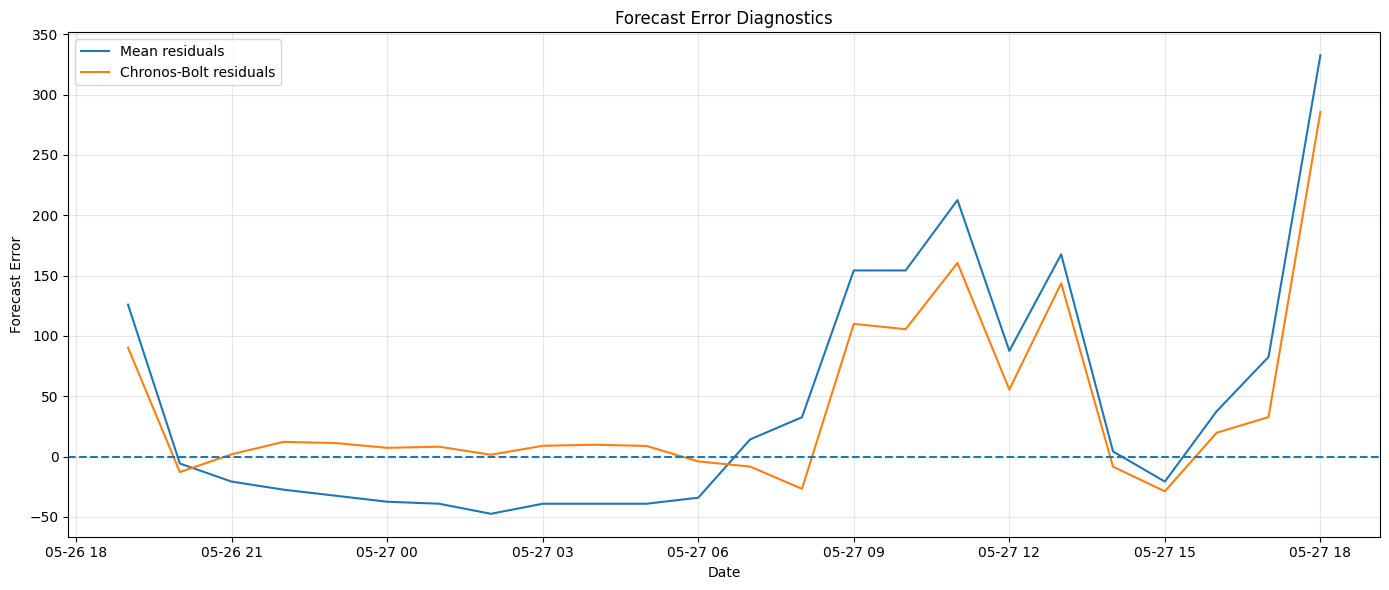

In [107]:
common_forecasts = {}
for model_name, predictions in all_forecasts.items():
    common_forecasts[model_name] = pd.Series(np.asarray(predictions)[:24],index=test.index)
residuals = {}
for model_name, predictions in common_forecasts.items():
    residuals[model_name] = (test - predictions)
# Find the best overall model
best_model = evaluation_results.loc[
    evaluation_results["RMSE"].idxmin(),
    "Model"
]
# Plot residuals
plt.figure(figsize=(14, 6))
plt.plot(
    test.index,
    residuals[strongest_benchmark],
    label=f"{strongest_benchmark} residuals"
)
plt.plot(
    test.index,
    residuals[best_model],
    label=f"{best_model} residuals"
)
plt.axhline(
    0,
    linestyle="--"
)
plt.title("Forecast Error Diagnostics")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

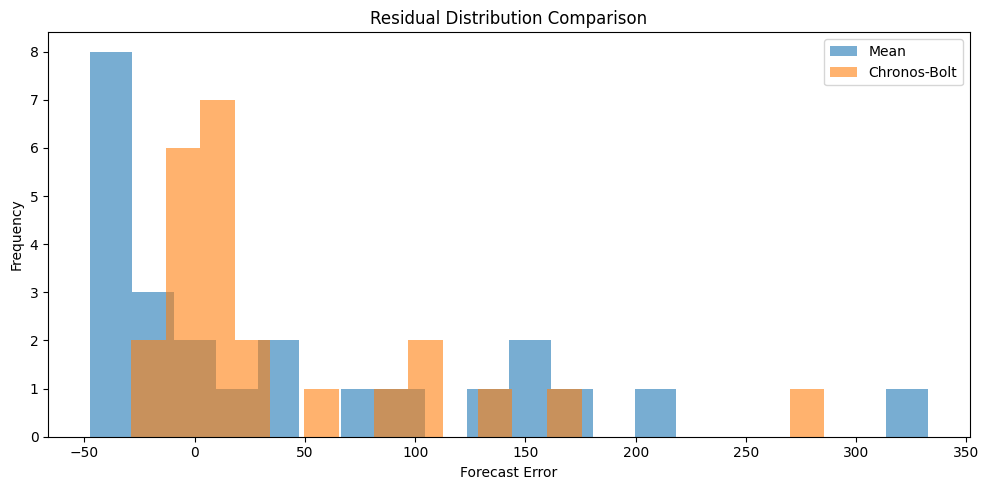

In [108]:
plt.figure(figsize=(10, 5))
plt.hist(
    residuals[strongest_benchmark],
    bins=20,
    alpha=0.6,
    label=strongest_benchmark
)
plt.hist(
    residuals[best_model],
    bins=20,
    alpha=0.6,
    label=best_model
)
plt.title("Residual Distribution Comparison")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
print("\n" + "=" * 70)
print("FINAL MODEL")
print("=" * 70)
best_result = evaluation_results.loc[evaluation_results["RMSE"].idxmin()]
print("Best overall model:", best_result["Model"])
print("MAE:", round(best_result["MAE"], 4))
print("RMSE:", round(best_result["RMSE"], 4))
print("MAPE (%):", round(best_result["MAPE (%)"], 4))


FINAL MODEL
Best overall model: Chronos-Bolt
MAE: 48.4122
RMSE: 83.2434
MAPE (%): 23.6853
